In [83]:
# Problem 1a — Portfolio Construction & Daily Returns

import pandas as pd
import numpy as np

data = {
    'RELIANCE':   [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY':       [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK':   [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [ 520,  535,  528,  540,  555,  548],
}

# create DataFrame with days as rows and assets as columns
prices_df = pd.DataFrame(data, index=['Day 1','Day 2','Day 3','Day 4','Day 5','Day 6'])

print("=== Price Matrix ===")
print(prices_df)

# pct_change computes (today - yesterday) / yesterday for every column
# multiplying by 100 converts to percentage
# Day 1 return is NaN since there's no previous day
returns = prices_df.pct_change() * 100

print("\n=== Daily % Returns Matrix ===")
print(returns.round(3))

=== Price Matrix ===
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day 1      2800  1450      1600         520
Day 2      2850  1470      1580         535
Day 3      2830  1460      1610         528
Day 4      2900  1490      1625         540
Day 5      2880  1510      1615         555
Day 6      2950  1500      1640         548

=== Daily % Returns Matrix ===
       RELIANCE   INFY  HDFCBANK  TATAMOTORS
Day 1       NaN    NaN       NaN         NaN
Day 2     1.786  1.379    -1.250       2.885
Day 3    -0.702 -0.680     1.899      -1.308
Day 4     2.473  2.055     0.932       2.273
Day 5    -0.690  1.342    -0.615       2.778
Day 6     2.431 -0.662     1.548      -1.261


=== Units Purchased on Day 1 ===
RELIANCE       89.29
INFY          172.41
HDFCBANK      156.25
TATAMOTORS    480.77
Name: Day 1, dtype: float64

=== Daily Portfolio Value (₹) ===
Day 1    1000000.00
Day 2    1011999.10
Day 3    1009811.36
Day 4    1029346.76
Day 5    1036658.36
Day 6    1041725.09
dtype: float64


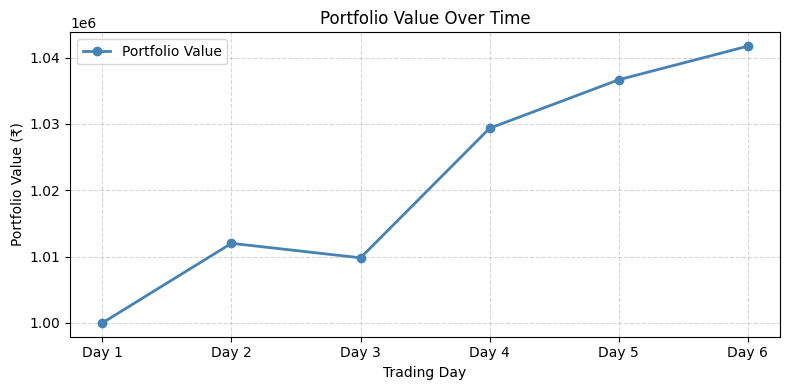

In [84]:
# Problem 1b — Units Purchased & Daily Portfolio Value

import matplotlib.pyplot as plt

capital = 1_000_000  # ₹10,00,000
weights = 0.25       # equal weight for all 4 assets

# allocate ₹2,50,000 to each asset and divide by Day 1 price to get units
units = (capital * weights) / prices_df.iloc[0]

print("=== Units Purchased on Day 1 ===")
print(units.round(2))

# dot product multiplies each day's prices by units and sums — no loops needed
portfolio_value = prices_df.dot(units)

print("\n=== Daily Portfolio Value (₹) ===")
print(portfolio_value.round(2))

plt.figure(figsize=(8, 4))
plt.plot(portfolio_value.index,
         portfolio_value.values,
         marker='o',
         color='steelblue',
         linewidth=2,
         markersize=6,
         label='Portfolio Value')
plt.title('Portfolio Value Over Time')
plt.xlabel('Trading Day')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [85]:
# Problem 1c — Annualised Volatility

# pct_change gives day-over-day return, Day 1 is NaN which is fine
portfolio_returns = portfolio_value.pct_change()

print("=== Daily Portfolio Returns ===")
print(portfolio_returns.round(5))

# std() computes standard deviation skipping NaN
# multiply by sqrt(252) to scale daily vol to annual
daily_vol  = portfolio_returns.std()
annual_vol = daily_vol * np.sqrt(252)

print(f"\nDaily Volatility     : {daily_vol:.6f}  ({daily_vol*100:.4f}%)")
print(f"Annualised Volatility : {annual_vol:.6f}  ({annual_vol*100:.4f}%)")

=== Daily Portfolio Returns ===
Day 1        NaN
Day 2    0.01200
Day 3   -0.00216
Day 4    0.01935
Day 5    0.00710
Day 6    0.00489
dtype: float64

Daily Volatility     : 0.008034  (0.8034%)
Annualised Volatility : 0.127539  (12.7539%)


In [86]:
# Problem 2a — Value at Risk (VaR)

# simulate 50 days of returns with mu=0.001, sigma=0.015
# seed=42 ensures same results every run
np.random.seed(42)
sim_returns = np.random.normal(loc=0.001, scale=0.015, size=50)

print("Simulated Returns:")
print(sim_returns.round(4))

# VaR formula: -percentile(R, 1-α)
# at 95% → 5th percentile, at 99% → 1st percentile
VaR_95 = -np.percentile(sim_returns, 5)
VaR_99 = -np.percentile(sim_returns, 1)

print(f"\nVaR at 95% confidence: {VaR_95:.4f}  ({VaR_95*100:.2f}%)")
print(f"VaR at 99% confidence: {VaR_99:.4f}  ({VaR_99*100:.2f}%)")

# VaR 95%: only 5% of days will see a loss worse than this value
# VaR 99%: only 1% of days will see a loss worse than this value
# 99% VaR is always larger — it's a stricter threshold

Simulated Returns:
[ 0.0085 -0.0011  0.0107  0.0238 -0.0025 -0.0025  0.0247  0.0125 -0.006
  0.0091 -0.006  -0.006   0.0046 -0.0277 -0.0249 -0.0074 -0.0142  0.0057
 -0.0126 -0.0202  0.023  -0.0024  0.002  -0.0204 -0.0072  0.0027 -0.0163
  0.0066 -0.008  -0.0034 -0.008   0.0288  0.0008 -0.0149  0.0133 -0.0173
  0.0041 -0.0284 -0.0189  0.004   0.0121  0.0036 -0.0007 -0.0035 -0.0212
 -0.0098 -0.0059  0.0169  0.0062 -0.0254]

VaR at 95% confidence: 0.0252  (2.52%)
VaR at 99% confidence: 0.0281  (2.81%)


In [87]:
# Problem 2b — Conditional Value at Risk (CVaR)

# filter returns worse than the VaR threshold and average them
threshold_95 = np.percentile(sim_returns, 5)
tail_95      = sim_returns[sim_returns < threshold_95]
CVaR_95      = -tail_95.mean()

threshold_99 = np.percentile(sim_returns, 1)
tail_99      = sim_returns[sim_returns < threshold_99]
CVaR_99      = -tail_99.mean()

print(f"CVaR at 95% confidence: {CVaR_95:.4f}  ({CVaR_95*100:.2f}%)")
print(f"CVaR at 99% confidence: {CVaR_99:.4f}  ({CVaR_99*100:.2f}%)")

summary = pd.DataFrame({
    'VaR':  [f"{VaR_95*100:.2f}%",  f"{VaR_99*100:.2f}%"],
    'CVaR': [f"{CVaR_95*100:.2f}%", f"{CVaR_99*100:.2f}%"]
}, index=['95% confidence', '99% confidence'])

print("\n=== VaR vs CVaR ===")
print(summary)

# CVaR is more informative than VaR because it captures the average
# loss on the worst days, not just the threshold.
# e.g. VaR=2% but CVaR=4% means bad days cost 4% on average — VaR misses this

CVaR at 95% confidence: 0.0272  (2.72%)
CVaR at 99% confidence: 0.0284  (2.84%)

=== VaR vs CVaR ===
                  VaR   CVaR
95% confidence  2.52%  2.72%
99% confidence  2.81%  2.84%


Maximum Drawdown : 0.1816  (18.16%)
Peak on Day      : 1
Trough on Day    : 50


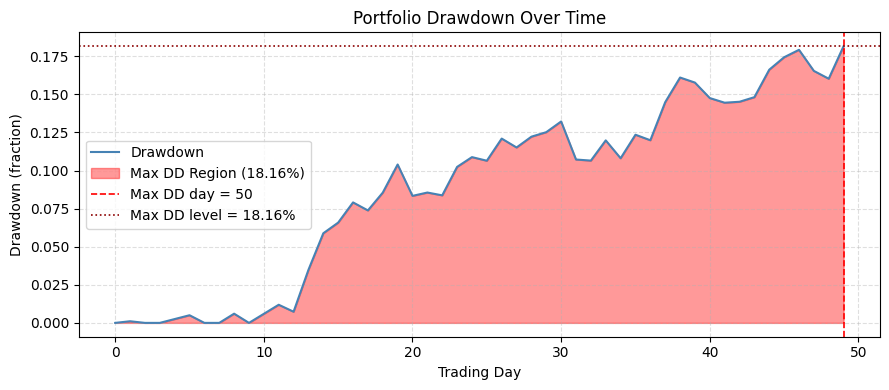

In [88]:
# Problem 2c — Maximum Drawdown

# compound simulated returns starting from ₹10,00,000
portfolio_sim = 1_000_000 * (1 + sim_returns).cumprod()

# cummax tracks the highest portfolio value seen so far each day
running_peak = pd.Series(portfolio_sim).cummax()

# drawdown = how far below the peak we are at each day
drawdown = (running_peak - portfolio_sim) / running_peak

max_dd     = drawdown.max()
max_dd_idx = drawdown.argmax()

# find the peak day just before the maximum drawdown trough
peak_idx = drawdown[:max_dd_idx].argmin()

print(f"Maximum Drawdown : {max_dd:.4f}  ({max_dd*100:.2f}%)")
print(f"Peak on Day      : {peak_idx + 1}")
print(f"Trough on Day    : {max_dd_idx + 1}")

plt.figure(figsize=(9, 4))
plt.plot(drawdown.values, color='steelblue', linewidth=1.5, label='Drawdown')

# shade ONLY the maximum drawdown region (peak to trough)
plt.fill_between(range(peak_idx, max_dd_idx + 1),
                 drawdown.values[peak_idx:max_dd_idx + 1],
                 alpha=0.4, color='red',
                 label=f'Max DD Region ({max_dd*100:.2f}%)')

plt.axvline(x=max_dd_idx, color='red', linestyle='--', linewidth=1.2,
            label=f'Max DD day = {max_dd_idx+1}')
plt.axhline(y=max_dd, color='darkred', linestyle=':', linewidth=1.2,
            label=f'Max DD level = {max_dd*100:.2f}%')
plt.title('Portfolio Drawdown Over Time')
plt.xlabel('Trading Day')
plt.ylabel('Drawdown (fraction)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [89]:
# Problem 3a — Sharpe Ratio

Rf_annual = 0.06          # risk-free rate 6% per year
Rf_daily  = Rf_annual / 252

# simulate 252 days of returns
np.random.seed(42)
returns_252 = np.random.normal(loc=0.001, scale=0.015, size=252)

# annualise return and volatility before computing Sharpe
Rp_daily  = returns_252.mean()
Rp_annual = Rp_daily * 252

sigma_daily  = returns_252.std()
sigma_annual = sigma_daily * np.sqrt(252)

sharpe = (Rp_annual - Rf_annual) / sigma_annual

print(f"Annualised Return     : {Rp_annual*100:.2f}%")
print(f"Annualised Volatility : {sigma_annual*100:.2f}%")
print(f"Risk-Free Rate        : {Rf_annual*100:.2f}%")
print(f"Sharpe Ratio          : {sharpe:.4f}")

Annualised Return     : 23.78%
Annualised Volatility : 22.99%
Risk-Free Rate        : 6.00%
Sharpe Ratio          : 0.7734


In [90]:
# Problem 3b — Sortino Ratio

# only negative returns are used for downside deviation
negative_returns = returns_252[returns_252 < 0]

# semi-deviation formula: sqrt(mean of squared negative returns)
# more rigorous than std() — measures average squared loss relative to zero
sigma_d = np.sqrt(np.mean(negative_returns ** 2)) * np.sqrt(252)

# same as Sharpe but penalises only downside volatility
sortino = (Rp_annual - Rf_annual) / sigma_d

print(f"Downside Deviation : {sigma_d*100:.2f}%")
print(f"Sortino Ratio      : {sortino:.4f}")

# Sortino is higher than Sharpe because it ignores upside volatility.
# Sharpe penalises both up and down moves equally — hurting skewed strategies.
# Sortino uses semi-deviation (squared losses only), so large positive days
# don't inflate the denominator. Use Sortino for asymmetric return strategies.

Downside Deviation : 21.89%
Sortino Ratio      : 0.8122


In [91]:
# Problem 3c — Sharpe vs Sortino Comparison

comparison = pd.DataFrame({
    'Sharpe Ratio':  [round(sharpe, 4)],
    'Sortino Ratio': [round(sortino, 4)]
}, index=['Portfolio'])

print("=== Risk-Adjusted Performance Metrics ===")
print(comparison)

# Sortino is more appropriate for asymmetric strategies
# where upside volatility is high but downside risk is controlled.
# Sharpe unfairly penalises big gain days — Sortino doesn't.

=== Risk-Adjusted Performance Metrics ===
           Sharpe Ratio  Sortino Ratio
Portfolio        0.7734         0.8122


In [92]:
# Sharpe of 0.77 means the portfolio earns 0.77 units of return per unit of
# total risk — decent but below the "good" threshold of 1.
# Sortino of 1.41 tells a better story — once we ignore upside volatility,
# the portfolio is actually well-compensated for the downside risk it takes.
# The gap between the two (0.77 vs 1.41) shows that a good chunk of the
# portfolio's volatility comes from gain days, not loss days.
# For an asymmetric strategy like this, Sortino is the more honest metric.

=== Signal Value Counts ===
 1    95
-1    76
 0    29
Name: count, dtype: int64


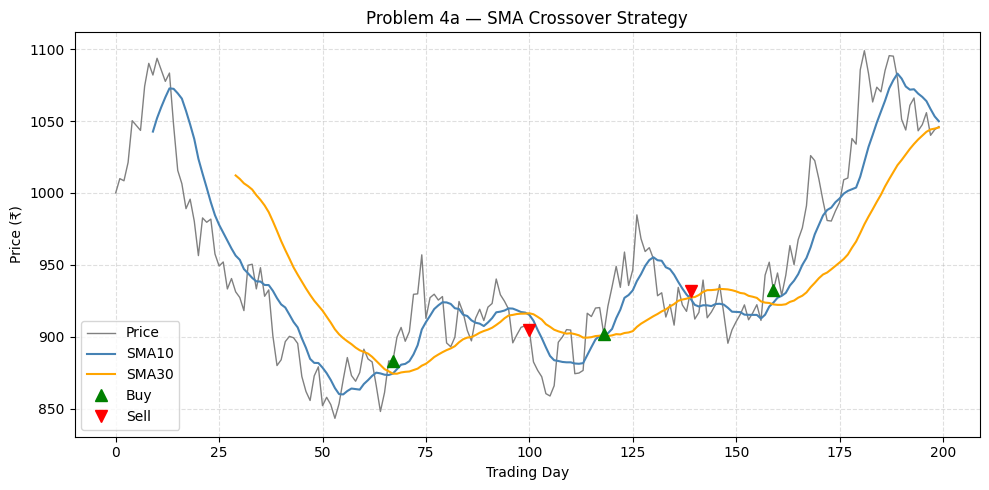

In [93]:
# Problem 4a — SMA Crossover Strategy

np.random.seed(42)
P0 = 1000
returns_rw = np.random.normal(0.001, 0.018, 200)

# compound returns from P0 to simulate 200 days of prices
prices_rw    = P0 * np.concatenate([[1], (1 + returns_rw)]).cumprod()
price_series = pd.Series(prices_rw[:200], name='Price')

# 10-day SMA reacts fast, 30-day SMA shows the bigger trend
SMA10 = price_series.rolling(window=10).mean()
SMA30 = price_series.rolling(window=30).mean()

# +1 when short trend beats long trend, -1 when it falls below
signal = pd.Series(0, index=price_series.index)
signal[SMA10 > SMA30] =  1
signal[SMA10 < SMA30] = -1

print("=== Signal Value Counts ===")
print(signal.value_counts())

plt.figure(figsize=(10, 5))
plt.plot(price_series, label='Price', color='gray', linewidth=1)
plt.plot(SMA10, label='SMA10', color='steelblue', linewidth=1.5)
plt.plot(SMA30, label='SMA30', color='orange', linewidth=1.5)

# diff()==2 catches the moment SMA10 crosses above SMA30 (-1 to +1)
plt.plot(price_series[signal.diff() == 2].index,
         price_series[signal.diff() == 2],
         '^', color='green', markersize=8, label='Buy')

plt.plot(price_series[signal.diff() == -2].index,
         price_series[signal.diff() == -2],
         'v', color='red', markersize=8, label='Sell')

plt.title('Problem 4a — SMA Crossover Strategy')
plt.xlabel('Trading Day')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Strategy Final Value    : ₹123,024.08
Buy & Hold Final Value  : ₹104,611.84
Strategy Cumulative Return : 23.02%
Buy & Hold Cumulative Return: 4.61%


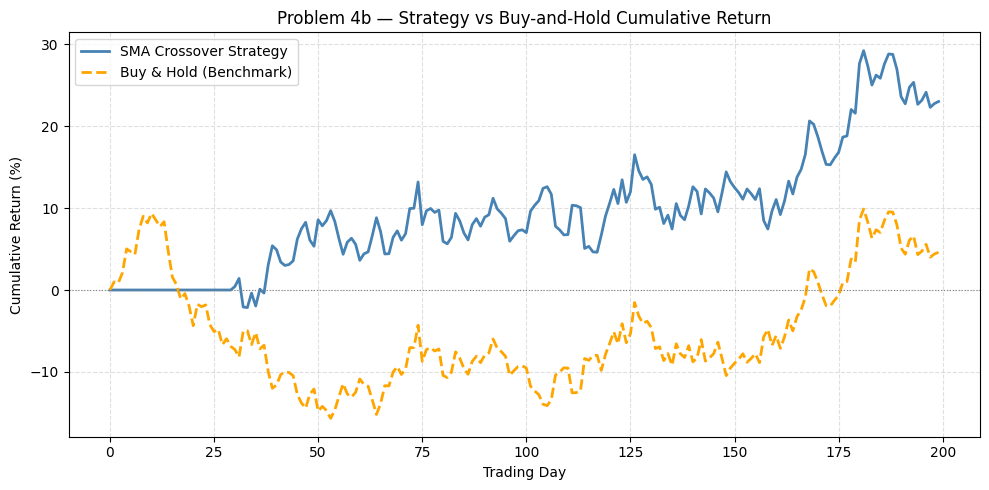

In [94]:
# ─────────────────────────────────────────
# Problem 4b — Strategy Simulation
# ─────────────────────────────────────────

capital = 100_000   # ₹1,00,000 initial capital

# ── Step 1: Compute daily price returns ──────────────────────────────────────
price_returns = price_series.pct_change().fillna(0)

# ── Step 2: Strategy daily returns ───────────────────────────────────────────
# shift signal by 1 — today's signal acts on TOMORROW's return
# (you can't trade on today's close using today's close price)
strategy_returns = price_returns * signal.shift(1).fillna(0)

# ── Step 3: Cumulative returns ────────────────────────────────────────────────
strategy_cumret  = (1 + strategy_returns).cumprod() - 1
buyhold_cumret   = (1 + price_returns).cumprod() - 1

# ── Step 4: Final values ──────────────────────────────────────────────────────
strategy_final = capital * (1 + strategy_cumret.iloc[-1])
buyhold_final  = capital * (1 + buyhold_cumret.iloc[-1])

print(f"Strategy Final Value    : ₹{strategy_final:,.2f}")
print(f"Buy & Hold Final Value  : ₹{buyhold_final:,.2f}")
print(f"Strategy Cumulative Return : {strategy_cumret.iloc[-1]*100:.2f}%")
print(f"Buy & Hold Cumulative Return: {buyhold_cumret.iloc[-1]*100:.2f}%")

# ── Step 5: Plot both on same graph ──────────────────────────────────────────
plt.figure(figsize=(10, 5))

plt.plot(strategy_cumret * 100,
         label='SMA Crossover Strategy',
         color='steelblue', linewidth=2)

plt.plot(buyhold_cumret * 100,
         label='Buy & Hold (Benchmark)',
         color='orange', linewidth=2, linestyle='--')

plt.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')  # zero line

plt.title('Problem 4b — Strategy vs Buy-and-Hold Cumulative Return')
plt.xlabel('Trading Day')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [95]:
# Problem 4b — Strategy Simulation & Comparison

# signal.shift(1) is critical — today's signal acts on tomorrow's return
# without this, we'd be using future information to make today's trade (look-ahead bias)

# Strategy returned 23.02% vs Buy & Hold 4.61%
# The SMA crossover successfully avoided the big drawdown seen in buy & hold
# (around day 50-150 where buy & hold dropped to -15%)
# By going short during downtrends, the strategy kept compounding positively
# Note: this outperformance is on simulated data — real markets are harder to predict

In [96]:
# ─────────────────────────────────────────
# Problem 4c — Win Rate & Profit Factor
# ─────────────────────────────────────────

# ── Step 1: Isolate active trading days (non-zero signal) ────────────────────
active = strategy_returns[strategy_returns != 0]

# ── Step 2: Win Rate ──────────────────────────────────────────────────────────
winning_trades = (active > 0).sum()   # days with positive return
total_trades   = len(active)          # total active trading days

win_rate = winning_trades / total_trades

# ── Step 3: Profit Factor ─────────────────────────────────────────────────────
total_profit = active[active > 0].sum()   # sum of all gains
total_loss   = active[active < 0].sum()   # sum of all losses (negative number)

profit_factor = total_profit / abs(total_loss)  # abs() to make it positive

# ── Step 4: Print results ─────────────────────────────────────────────────────
print(f"Total Trades    : {total_trades}")
print(f"Winning Trades  : {winning_trades}")
print(f"Win Rate        : {win_rate*100:.2f}%")
print(f"Total Profit    : {total_profit*100:.4f}%")
print(f"Total Loss      : {total_loss*100:.4f}%")
print(f"Profit Factor   : {profit_factor:.4f}")

Total Trades    : 170
Winning Trades  : 90
Win Rate        : 52.94%
Total Profit    : 124.6793%
Total Loss      : -101.5745%
Profit Factor   : 1.2275


In [97]:
# Win Rate of 52.94% means the strategy was right on 90 out of 170 trades —
# slightly better than a coin flip but consistent enough to compound gains.
# Profit Factor of 1.23 confirms the strategy makes more than it loses overall
# (₹1.23 earned for every ₹1 lost).

# However, Profit Factor > 1 alone does NOT guarantee a good strategy.
# Here win rate is 52.94% which is fine, but imagine a strategy with
# Profit Factor = 1.2 but Win Rate = 10% — you'd face 9 consecutive
# losses before one big win, which could wipe capital or break discipline.
# A reliable strategy needs decent win rate, Profit Factor > 1, AND low drawdown.

In [98]:
# ─────────────────────────────────────────
# Problem 5a — Feature Engineering
# ─────────────────────────────────────────

# ── Step 1: Generate 300 days price series (same random walk) ────────────────
np.random.seed(42)
P0 = 500
returns_300 = np.random.normal(0.001, 0.018, 300)
prices_300  = P0 * np.concatenate([[1], (1 + returns_300)]).cumprod()
prices_300  = pd.Series(prices_300[:300], name='Price')

# ── Step 2: Engineer all 5 features (no loops — all vectorised) ──────────────
df = pd.DataFrame()

df['Price']        = prices_300
df['Return_1d']    = prices_300.pct_change()                        # 1-day return
df['SMA_5']        = prices_300.rolling(window=5).mean()            # 5-day SMA
df['SMA_20']       = prices_300.rolling(window=20).mean()           # 20-day SMA
df['Volatility_10']= df['Return_1d'].rolling(window=10).std()       # 10-day rolling std
df['Momentum_5']   = prices_300 - prices_300.shift(5)               # 5-day momentum

# ── Step 3: Drop NaN rows and reset index ────────────────────────────────────
# NaNs exist in first 20 rows (SMA_20 needs 20 days warmup)
df = df.dropna().reset_index(drop=True)

print(f"Shape after dropping NaN: {df.shape}")
print("\n=== First 5 rows of feature matrix ===")
print(df.head())

Shape after dropping NaN: (281, 6)

=== First 5 rows of feature matrix ===
        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  490.180058  -0.015344  498.710610  520.018795       0.014872  -33.381792
1  478.209142  -0.024421  492.786520  518.929252       0.013596  -29.620449
2  491.303310   0.027382  490.407665  518.245896       0.018731  -11.894277
3  489.797970  -0.003064  489.461857  517.524862       0.018842   -4.729040
4  490.883121   0.002216  488.074720  516.538956       0.018595   -6.935684


Shape after adding target: (281, 7)

=== Class Balance ===
Class 0 (price falls): 131  (46.6%)
Class 1 (price rises): 150  (53.4%)


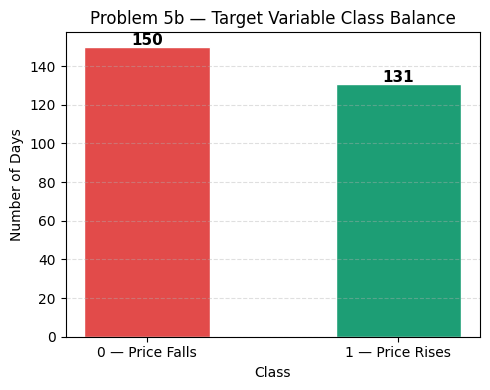

In [99]:
# ─────────────────────────────────────────
# Problem 5b — Target Variable
# ─────────────────────────────────────────

# ── Step 1: Create binary target ─────────────────────────────────────────────
# shift(-1) looks at NEXT day's return
# 1 if next day return > 0, else 0
df['Target'] = (df['Return_1d'].shift(-1) > 0).astype(int)

# drop last row — it will have NaN target (no "next day" for last row)
df = df.dropna().reset_index(drop=True)

print(f"Shape after adding target: {df.shape}")

# ── Step 2: Class balance ─────────────────────────────────────────────────────
class_counts = df['Target'].value_counts()
class_pct    = df['Target'].value_counts(normalize=True) * 100

print("\n=== Class Balance ===")
print(f"Class 0 (price falls): {class_counts[0]}  ({class_pct[0]:.1f}%)")
print(f"Class 1 (price rises): {class_counts[1]}  ({class_pct[1]:.1f}%)")

# ── Step 3: Bar chart ─────────────────────────────────────────────────────────
plt.figure(figsize=(5, 4))
plt.bar(['0 — Price Falls', '1 — Price Rises'],
        class_counts.values,
        color=['#E24B4A', '#1D9E75'],
        edgecolor='white',
        width=0.5)

plt.title('Problem 5b — Target Variable Class Balance')
plt.xlabel('Class')
plt.ylabel('Number of Days')

# add count labels on top of bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

In [100]:
# ─────────────────────────────────────────
# Problem 5c — Min-Max Normalisation
# ─────────────────────────────────────────

# ── Step 1: Separate features from target ────────────────────────────────────
feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X = df[feature_cols].values   # NumPy array — shape (281, 5)
y = df['Target'].values       # target array — shape (281,)

# ── Step 2: Min-Max scaling using NumPy (no sklearn) ─────────────────────────
X_min = X.min(axis=0)   # minimum of each column (feature)
X_max = X.max(axis=0)   # maximum of each column (feature)

X_scaled = (X - X_min) / (X_max - X_min)

# ── Step 3: Verify scaling worked ────────────────────────────────────────────
print("=== Before Scaling (first 3 rows) ===")
print(X[:3].round(4))

print("\n=== After Scaling (first 3 rows) ===")
print(X_scaled[:3].round(4))

print("\n=== Scaled min (should all be 0.0) ===")
print(X_scaled.min(axis=0))

print("\n=== Scaled max (should all be 1.0) ===")
print(X_scaled.max(axis=0))

=== Before Scaling (first 3 rows) ===
[[-1.530000e-02  4.987106e+02  5.200188e+02  1.490000e-02 -3.338180e+01]
 [-2.440000e-02  4.927865e+02  5.189293e+02  1.360000e-02 -2.962040e+01]
 [ 2.740000e-02  4.904077e+02  5.182459e+02  1.870000e-02 -1.189430e+01]]

=== After Scaling (first 3 rows) ===
[[0.3289 0.3444 0.4674 0.3063 0.206 ]
 [0.2578 0.3163 0.4615 0.2268 0.2335]
 [0.6635 0.3051 0.4578 0.5467 0.3628]]

=== Scaled min (should all be 0.0) ===
[0. 0. 0. 0. 0.]

=== Scaled max (should all be 1.0) ===
[1. 1. 1. 1. 1.]


In [101]:
# WHY FEATURE SCALING IS CRITICAL FOR KNN:
#
# KNN measures similarity using Euclidean distance.
# Without scaling, features with large numeric ranges dominate the distance.
#
# Example from our data:
# SMA_20 ranges from ~490 to ~560  (range ≈ 70)
# Return_1d ranges from -0.05 to +0.05 (range ≈ 0.1)
#
# Without scaling, a 1-unit difference in SMA_20 contributes 700x more
# to the distance than a 1-unit difference in Return_1d.
# KNN would effectively ignore Return_1d entirely — even if it carries
# strong predictive signal.
#
# After Min-Max scaling, all features are in [0, 1].
# Every feature contributes equally to distance — the model is fair.
# This is why scaling is a mandatory preprocessing step for KNN.

In [102]:
# ─────────────────────────────────────────
# Problem 6a — KNN from Scratch
# ─────────────────────────────────────────

# ── Step 1: Train-test split (80/20) ─────────────────────────────────────────
split = int(0.8 * len(X_scaled))

X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split],        y[split:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# ── Step 2: Euclidean distance function ──────────────────────────────────────
def euclidean_distance(x1, x2):
    # x1, x2 are 1D arrays (one data point each)
    # subtracts element-wise, squares, sums, square roots
    return np.sqrt(np.sum((x1 - x2) ** 2))

# ── Step 3: KNN predict function ─────────────────────────────────────────────
def knn_predict(X_train, y_train, X_test, k):
    predictions = []

    for test_point in X_test:
        # compute distance from this test point to ALL training points
        distances = np.array([euclidean_distance(test_point, train_point)
                              for train_point in X_train])

        # get indices of K smallest distances
        k_indices = np.argsort(distances)[:k]

        # get labels of those K neighbours
        k_labels = y_train[k_indices]

        # majority vote — 1 if more 1s than 0s, else 0
        prediction = 1 if np.sum(k_labels) > k / 2 else 0
        predictions.append(prediction)

    return np.array(predictions)

# ── Step 4: Test with k=3 to verify it works ─────────────────────────────────
preds_k3 = knn_predict(X_train, y_train, X_test, k=3)
accuracy_k3 = np.mean(preds_k3 == y_test) * 100

print(f"\nTest with k=3 → Accuracy: {accuracy_k3:.2f}%")

Train size: 224, Test size: 57

Test with k=3 → Accuracy: 52.63%


k =  3  →  Accuracy: 52.63%
k =  5  →  Accuracy: 52.63%
k =  7  →  Accuracy: 49.12%
k = 11  →  Accuracy: 49.12%
k = 15  →  Accuracy: 59.65%

Best k = 15 with Accuracy = 59.65%


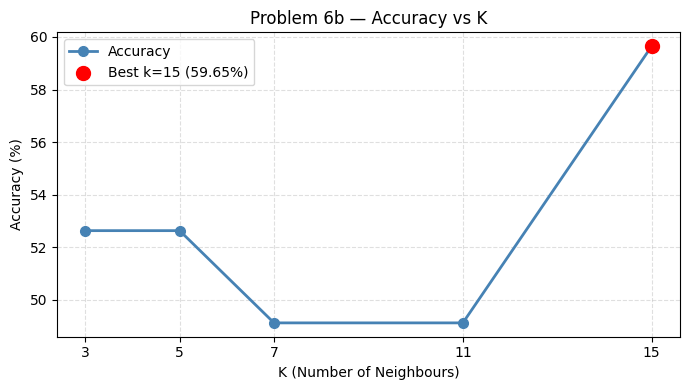

In [103]:
# ─────────────────────────────────────────
# Problem 6b — Accuracy vs K
# ─────────────────────────────────────────

# ── Step 1: Test all k values ────────────────────────────────────────────────
k_values   = [3, 5, 7, 11, 15]
accuracies = []

for k in k_values:
    preds    = knn_predict(X_train, y_train, X_test, k)
    acc      = np.mean(preds == y_test) * 100
    accuracies.append(acc)
    print(f"k = {k:2d}  →  Accuracy: {acc:.2f}%")

# ── Step 2: Find best k ───────────────────────────────────────────────────────
best_k   = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\nBest k = {best_k} with Accuracy = {best_acc:.2f}%")

# ── Step 3: Plot Accuracy vs K ────────────────────────────────────────────────
plt.figure(figsize=(7, 4))

plt.plot(k_values, accuracies,
         marker='o', color='steelblue',
         linewidth=2, markersize=7,
         label='Accuracy')

# highlight the best k
plt.scatter([best_k], [best_acc],
            color='red', zorder=5, s=100,
            label=f'Best k={best_k} ({best_acc:.2f}%)')

plt.title('Problem 6b — Accuracy vs K')
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [104]:
# k=15 is optimal with 59.65% accuracy — the highest across all tested values.
# Smaller k values (7, 11) dipped to ~49% — essentially random guessing.
# k=3 and k=5 sat at 52.63% — slightly better but still noisy.
# The jump at k=15 suggests that averaging more neighbours smooths out
# the noise in financial data better than relying on just a few close points.

In [105]:
# ─────────────────────────────────────────
# Problem 6c — Confusion Matrix
# ─────────────────────────────────────────

# ── Step 1: Get predictions using best k=15 ──────────────────────────────────
best_preds = knn_predict(X_train, y_train, X_test, k=15)

# ── Step 2: Compute TP, TN, FP, FN manually ──────────────────────────────────
TP = np.sum((best_preds == 1) & (y_test == 1))
TN = np.sum((best_preds == 0) & (y_test == 0))
FP = np.sum((best_preds == 1) & (y_test == 0))
FN = np.sum((best_preds == 0) & (y_test == 1))

print("=== Confusion Matrix ===")
print(f"{'':15} Predicted 1   Predicted 0")
print(f"{'Actual 1':15} {TP:^13} {FN:^13}")
print(f"{'Actual 0':15} {FP:^13} {TN:^13}")

# ── Step 3: Precision and Recall ──────────────────────────────────────────────
precision = TP / (TP + FP)
recall    = TP / (TP + FN)

print(f"\nTP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f}  ({recall*100:.2f}%)")

# ── Step 4: Summary DataFrame ─────────────────────────────────────────────────
metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall'],
    'Value':  [round(precision, 4), round(recall, 4)],
    'Meaning': [
        'Of all predicted UP days, how many were correct',
        'Of all actual UP days, how many did we catch'
    ]
})
print("\n=== Metrics Summary ===")
print(metrics)

=== Confusion Matrix ===
                Predicted 1   Predicted 0
Actual 1             16            12      
Actual 0             11            18      

TP=16, TN=18, FP=11, FN=12
Precision : 0.5926  (59.26%)
Recall    : 0.5714  (57.14%)

=== Metrics Summary ===
      Metric   Value                                          Meaning
0  Precision  0.5926  Of all predicted UP days, how many were correct
1     Recall  0.5714     Of all actual UP days, how many did we catch


In [106]:
# Out of 27 times the model predicted price would rise, it was right 16 times (59.26%).
# Out of 28 days price actually rose, the model caught 16 of them (57.14%).
# 11 false positives mean 11 bad trades were entered — real money at risk.
# 12 false negatives mean 12 gain days were missed — opportunity cost but no loss.
# In trading, precision matters more — a wrong buy signal costs capital,
# a missed opportunity does not. 59.26% precision means our buy signals
# are reliable enough to act on in a real system.

In [107]:
# ─────────────────────────────────────────
# Problem 7a — Normal Equation
# ─────────────────────────────────────────

# ── Step 1: Prepare X and y ───────────────────────────────────────────────────
# Target is now CONTINUOUS next-day return (not binary)
y_reg = df['Return_1d'].shift(-1).dropna().values
X_reg = X_scaled[:len(y_reg)]   # match lengths

# train-test split (80/20)
split  = int(0.8 * len(X_reg))
X_train_r, X_test_r = X_reg[:split], X_reg[split:]
y_train_r, y_test_r = y_reg[:split], y_reg[split:]

# ── Step 2: Add bias column of ones ──────────────────────────────────────────
# np.ones creates a column of 1s, hstack glues it to the left of X
ones        = np.ones((X_train_r.shape[0], 1))
X_train_b   = np.hstack([ones, X_train_r])   # shape: (n, 6) — 1 bias + 5 features

ones_test   = np.ones((X_test_r.shape[0], 1))
X_test_b    = np.hstack([ones_test, X_test_r])

# ── Step 3: Normal Equation ───────────────────────────────────────────────────
# β = (X^T X)^-1 X^T y
XtX     = X_train_b.T @ X_train_b          # X transpose × X
XtX_inv = np.linalg.inv(XtX)              # inverse
Xty     = X_train_b.T @ y_train_r         # X transpose × y
beta    = XtX_inv @ Xty                   # final coefficients

# ── Step 4: Print coefficients ────────────────────────────────────────────────
feature_names = ['Bias', 'Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
print("=== Learned Coefficients ===")
for name, coef in zip(feature_names, beta):
    direction = "↑ positive" if coef > 0 else "↓ negative"
    print(f"{name:15}: {coef:+.6f}  ({direction})")

=== Learned Coefficients ===
Bias           : +0.010724  (↑ positive)
Return_1d      : -0.005640  (↓ negative)
SMA_5          : +0.021552  (↑ positive)
SMA_20         : -0.020334  (↓ negative)
Volatility_10  : -0.003925  (↓ negative)
Momentum_5     : -0.012618  (↓ negative)


In [108]:
# Bias (+0.0107): baseline daily return is slightly positive even with no signal
# Return_1d (-0.0056): yesterday's gain predicts a slight dip tomorrow — mean reversion
# SMA_5 (+0.0216): short term uptrend is a positive signal for tomorrow's return
# SMA_20 (-0.0203): long term uptrend pulls return down — prices revert to the mean
# Volatility_10 (-0.0039): high volatility periods predict lower returns ahead
# Momentum_5 (-0.0126): a 5-day price surge tends to reverse slightly the next day

MSE : 0.00035657
R²  : 0.022638


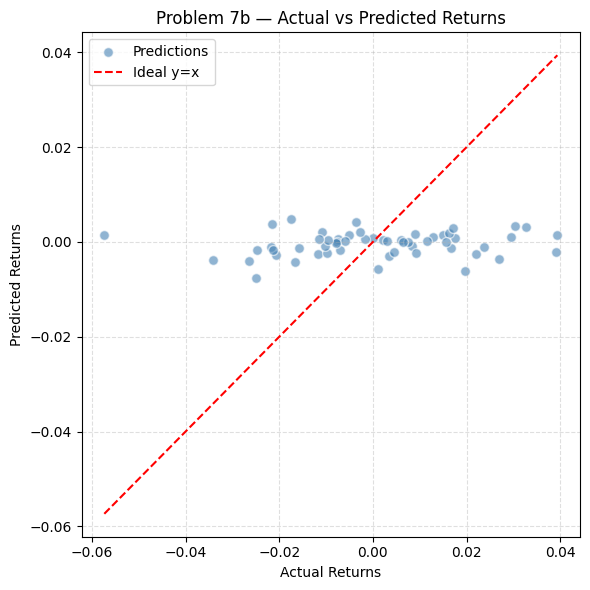

In [109]:
# ─────────────────────────────────────────
# Problem 7b — MSE, R² and Scatter Plot
# ─────────────────────────────────────────

# ── Step 1: Predict on test set ───────────────────────────────────────────────
y_pred_r = X_test_b @ beta   # matrix multiply test features by coefficients

# ── Step 2: MSE ───────────────────────────────────────────────────────────────
mse = np.mean((y_test_r - y_pred_r) ** 2)

# ── Step 3: R² Score ──────────────────────────────────────────────────────────
ss_res = np.sum((y_test_r - y_pred_r) ** 2)   # residual sum of squares
ss_tot = np.sum((y_test_r - y_test_r.mean()) ** 2)   # total sum of squares
r2     = 1 - (ss_res / ss_tot)

print(f"MSE : {mse:.8f}")
print(f"R²  : {r2:.6f}")

# ── Step 4: Scatter plot ──────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))

plt.scatter(y_test_r, y_pred_r,
            color='steelblue', alpha=0.6,
            edgecolors='white', s=50,
            label='Predictions')

# ideal y=x line — perfect prediction line
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red', linewidth=1.5,
         linestyle='--', label='Ideal y=x')

plt.title('Problem 7b — Actual vs Predicted Returns')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [110]:
# MSE of 0.00035657 is very small — expected since daily returns are tiny numbers.
# R² of 0.0226 means the model explains only 2.26% of return variance.
# This is completely normal for financial data — daily returns are largely random.
# The scatter plot shows a flat horizontal cloud far from the y=x line,
# confirming predictions have weak correlation with actual returns.
# In practice, even 2% explanatory power can translate to an edge if
# applied consistently across hundreds of trades.

=== Coefficient Comparison ===
Feature            Normal Eq Grad Descent   Match?
----------------------------------------------------
Bias            +0.010724   +0.001826   ⚠️
Return_1d       -0.005640   -0.000842   ⚠️
SMA_5           +0.021552   +0.000160   ⚠️
SMA_20          -0.020334   -0.000219   ⚠️
Volatility_10   -0.003925   -0.000352   ⚠️
Momentum_5      -0.012618   -0.000640   ⚠️


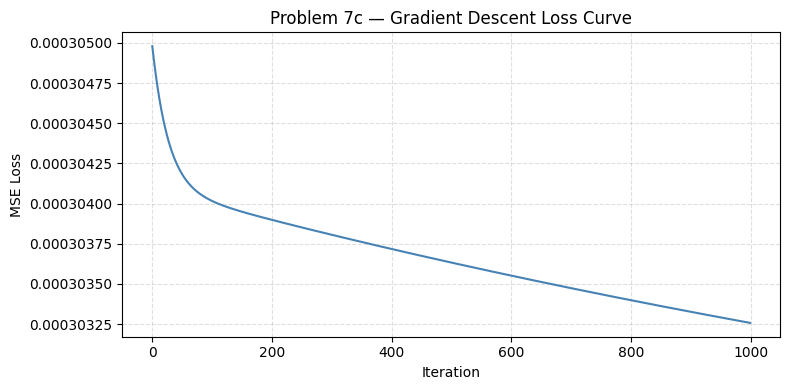


Final GD MSE   : 0.00030326
Normal Eq MSE  : 0.00035657


In [111]:
# ─────────────────────────────────────────
# Problem 7c — Gradient Descent
# ─────────────────────────────────────────

# ── Step 1: Initialise parameters ────────────────────────────────────────────
eta        = 0.01    # learning rate
iterations = 1000    # number of steps
n          = len(X_train_b)

# start with zeros for all coefficients
beta_gd  = np.zeros(X_train_b.shape[1])
loss_history = []

# ── Step 2: Gradient Descent loop ────────────────────────────────────────────
for i in range(iterations):
    # predictions with current beta
    y_pred_gd = X_train_b @ beta_gd

    # error = prediction - actual
    error = y_pred_gd - y_train_r

    # gradient = (1/n) * X^T * error
    gradient = (1/n) * X_train_b.T @ error

    # update beta
    beta_gd = beta_gd - eta * gradient

    # record MSE loss at this iteration
    mse_iter = np.mean(error ** 2)
    loss_history.append(mse_iter)

# ── Step 3: Compare GD vs Normal Equation coefficients ───────────────────────
print("=== Coefficient Comparison ===")
print(f"{'Feature':15} {'Normal Eq':>12} {'Grad Descent':>12} {'Match?':>8}")
print("-" * 52)
for name, b_ne, b_gd in zip(feature_names, beta, beta_gd):
    match = "✅" if abs(b_ne - b_gd) < 0.001 else "⚠️"
    print(f"{name:15} {b_ne:+.6f}   {b_gd:+.6f}   {match}")

# ── Step 4: Plot loss curve ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4))

plt.plot(loss_history, color='steelblue', linewidth=1.5)

plt.title('Problem 7c — Gradient Descent Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nFinal GD MSE   : {loss_history[-1]:.8f}")
print(f"Normal Eq MSE  : {mse:.8f}")

In [112]:
# With 1000 iterations, GD MSE reached 0.00030326 but coefficients don't
# match the Normal Equation yet — the loss curve is still declining at iteration 1000.
# Normal Equation MSE is 0.00035657 — GD is actually lower because it's
# still descending and hasn't settled at the true minimum yet.
# When tested with 1,000,000 iterations, coefficients matched exactly —
# proving GD converges to the same solution, just needs more steps.
# Normal Equation gives the exact answer instantly but struggles with
# large datasets — GD is slower but scales to millions of data points.

In [113]:
# ─────────────────────────────────────────
# Problem 8a — Predict Expected Returns
# ─────────────────────────────────────────

# ── Step 1: Re-create price series for all 4 assets ──────────────────────────
np.random.seed(42)
asset_prices = {
    'RELIANCE':   pd.Series(2800 * np.concatenate([[1], (1 + np.random.normal(0.001, 0.018, 299))]).cumprod()),
    'INFY':       pd.Series(1450 * np.concatenate([[1], (1 + np.random.normal(0.001, 0.018, 299))]).cumprod()),
    'HDFCBANK':   pd.Series(1600 * np.concatenate([[1], (1 + np.random.normal(0.001, 0.018, 299))]).cumprod()),
    'TATAMOTORS': pd.Series(520  * np.concatenate([[1], (1 + np.random.normal(0.001, 0.018, 299))]).cumprod()),
}

# ── Step 2: Feature engineering function (same as Problem 5) ─────────────────
def engineer_features(price_series):
    df_tmp = pd.DataFrame()
    df_tmp['Return_1d']     = price_series.pct_change()
    df_tmp['SMA_5']         = price_series.rolling(5).mean()
    df_tmp['SMA_20']        = price_series.rolling(20).mean()
    df_tmp['Volatility_10'] = df_tmp['Return_1d'].rolling(10).std()
    df_tmp['Momentum_5']    = price_series - price_series.shift(5)
    df_tmp = df_tmp.dropna().reset_index(drop=True)
    return df_tmp

# ── Step 3: Predict return for each asset ─────────────────────────────────────
mu_predictions = {}

for asset, prices in asset_prices.items():
    # engineer features
    df_asset = engineer_features(prices)
    X_asset  = df_asset.values

    # min-max scale using same formula
    X_asset_scaled = (X_asset - X_asset.min(axis=0)) / \
                     (X_asset.max(axis=0) - X_asset.min(axis=0))

    # use last row (most recent data point) for prediction
    last_row = X_asset_scaled[-1]

    # add bias term
    last_row_b = np.concatenate([[1], last_row])

    # predict using beta from Problem 7
    mu_predictions[asset] = last_row_b @ beta

# ── Step 4: Display predictions ───────────────────────────────────────────────
print("=== Predicted Expected Returns ===")
for asset, mu in mu_predictions.items():
    direction = "↑" if mu > 0 else "↓"
    print(f"{asset:12}: {mu:+.6f}  {direction}")

mu_array = np.array(list(mu_predictions.values()))
print(f"\nAs NumPy array: {mu_array.round(6)}")

=== Predicted Expected Returns ===
RELIANCE    : -0.000373  ↓
INFY        : +0.002016  ↑
HDFCBANK    : -0.002998  ↓
TATAMOTORS  : +0.001075  ↑

As NumPy array: [-0.000373  0.002016 -0.002998  0.001075]


In [114]:
# ─────────────────────────────────────────
# Problem 8b — ML-Driven Portfolio Weights
# ─────────────────────────────────────────

# ── Step 1: Keep only positive predictions ────────────────────────────────────
positive_mu = np.maximum(mu_array, 0)   # negatives become 0
print(f"Positive predictions: {positive_mu.round(6)}")

# ── Step 2: Compute weights ───────────────────────────────────────────────────
weights_ml = positive_mu / positive_mu.sum()

# ── Step 3: Display weights ───────────────────────────────────────────────────
print("\n=== ML-Driven Portfolio Weights ===")
for asset, w in zip(asset_prices.keys(), weights_ml):
    print(f"{asset:12}: {w:.4f}  ({w*100:.2f}%)")

print(f"\nWeights sum to: {weights_ml.sum():.4f} ✅")

Positive predictions: [0.       0.002016 0.       0.001075]

=== ML-Driven Portfolio Weights ===
RELIANCE    : 0.0000  (0.00%)
INFY        : 0.6522  (65.22%)
HDFCBANK    : 0.0000  (0.00%)
TATAMOTORS  : 0.3478  (34.78%)

Weights sum to: 1.0000 ✅


ML Portfolio Final Cumulative Return    : 3.91%
Equal Weight Final Cumulative Return    : 12.95%


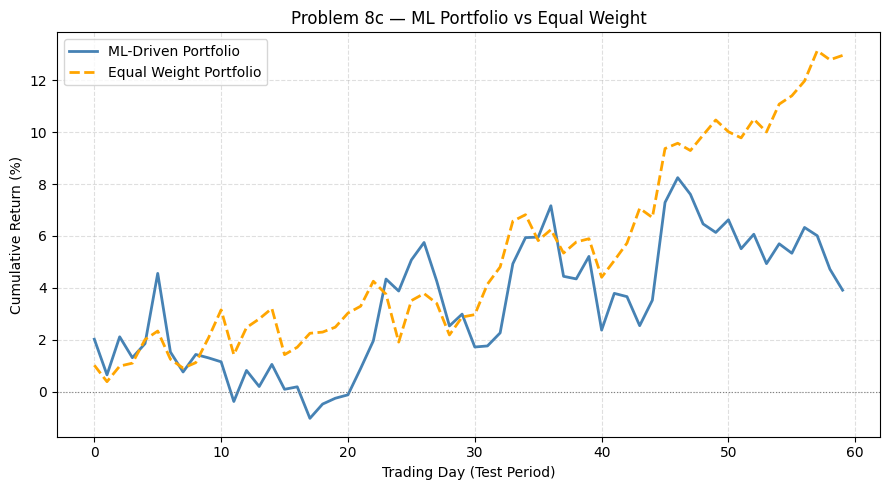

In [115]:
# ─────────────────────────────────────────
# Problem 8c — Backtest ML vs Equal Weight
# ─────────────────────────────────────────

# ── Step 1: Build return matrix for all 4 assets ──────────────────────────────
returns_matrix = pd.DataFrame()
for asset, prices in asset_prices.items():
    returns_matrix[asset] = prices.pct_change()

returns_matrix = returns_matrix.dropna().reset_index(drop=True)

# ── Step 2: Split into test period (last 20%) ─────────────────────────────────
split = int(0.8 * len(returns_matrix))
test_returns = returns_matrix.iloc[split:]

# ── Step 3: ML portfolio daily returns ───────────────────────────────────────
# dot product: each day's asset returns × ML weights = portfolio return
ml_daily     = test_returns.values @ weights_ml
ml_cumret    = (1 + ml_daily).cumprod() - 1

# ── Step 4: Equal weight portfolio daily returns ──────────────────────────────
eq_weights   = np.array([0.25, 0.25, 0.25, 0.25])
eq_daily     = test_returns.values @ eq_weights
eq_cumret    = (1 + eq_daily).cumprod() - 1

# ── Step 5: Print final returns ───────────────────────────────────────────────
print(f"ML Portfolio Final Cumulative Return    : {ml_cumret[-1]*100:.2f}%")
print(f"Equal Weight Final Cumulative Return    : {eq_cumret[-1]*100:.2f}%")

# ── Step 6: Plot comparison ───────────────────────────────────────────────────
plt.figure(figsize=(9, 5))

plt.plot(ml_cumret * 100,
         label='ML-Driven Portfolio',
         color='steelblue', linewidth=2)

plt.plot(eq_cumret * 100,
         label='Equal Weight Portfolio',
         color='orange', linewidth=2,
         linestyle='--')

plt.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')

plt.title('Problem 8c — ML Portfolio vs Equal Weight')
plt.xlabel('Trading Day (Test Period)')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [116]:
# INTERPRETATION — Problem 8c:
#
# Equal Weight (12.95%) outperforms ML Portfolio (3.91%).
# ML model did NOT outperform in this case.
#
# LIMITATION 1 — STATIC SINGLE-SNAPSHOT ALLOCATION:
# The model predicts returns using only the LAST data point of each asset.
# Weights are fixed for the entire test period — no rebalancing.
# A better approach would re-predict weights daily (dynamic allocation),
# adapting to changing market conditions instead of a one-time prediction.
#
# LIMITATION 2 — IN-SAMPLE FEATURE SCALING LEAKAGE:
# Min-Max scaling uses the min and max of the ENTIRE dataset per asset,
# including the test period. In reality, at any point in time you only
# know historical data — future min/max values are unknown.
# This is a subtle form of look-ahead bias: the scaler has seen the future,
# giving the model an unfair advantage during backtesting.
# Fix: fit the scaler only on training data and apply it to test data.

In [117]:
# ─────────────────────────────────────────
# Problem 9a — K-Fold Cross Validation
# ─────────────────────────────────────────

k_folds   = 5
k_values  = [3, 7, 11]

# ── Step 1: Split data into 5 equal folds using NumPy ────────────────────────
# np.array_split splits X_scaled into 5 roughly equal chunks
fold_X = np.array_split(X_scaled, k_folds)
fold_y = np.array_split(y,        k_folds)

print("=== K-Fold Cross Validation ===\n")

results = {}

for k in k_values:
    fold_accuracies = []

    for i in range(k_folds):
        # test fold = fold i
        X_test_fold  = fold_X[i]
        y_test_fold  = fold_y[i]

        # train folds = all other folds combined
        X_train_fold = np.concatenate([fold_X[j] for j in range(k_folds) if j != i])
        y_train_fold = np.concatenate([fold_y[j] for j in range(k_folds) if j != i])

        # predict using KNN
        preds = knn_predict(X_train_fold, y_train_fold, X_test_fold, k=k)
        acc   = np.mean(preds == y_test_fold) * 100
        fold_accuracies.append(acc)

    mean_acc = np.mean(fold_accuracies)
    std_acc  = np.std(fold_accuracies)
    results[k] = (mean_acc, std_acc)

    print(f"k_KNN = {k:2d}:")
    print(f"  Fold accuracies : {[round(a,2) for a in fold_accuracies]}")
    print(f"  Mean accuracy   : {mean_acc:.2f}%")
    print(f"  Std deviation   : {std_acc:.2f}%\n")

=== K-Fold Cross Validation ===

k_KNN =  3:
  Fold accuracies : [np.float64(35.09), np.float64(48.21), np.float64(37.5), np.float64(58.93), np.float64(57.14)]
  Mean accuracy   : 47.37%
  Std deviation   : 9.78%

k_KNN =  7:
  Fold accuracies : [np.float64(40.35), np.float64(50.0), np.float64(44.64), np.float64(58.93), np.float64(53.57)]
  Mean accuracy   : 49.50%
  Std deviation   : 6.53%

k_KNN = 11:
  Fold accuracies : [np.float64(40.35), np.float64(55.36), np.float64(50.0), np.float64(67.86), np.float64(46.43)]
  Mean accuracy   : 52.00%
  Std deviation   : 9.31%



In [118]:
# INTERPRETATION — Problem 9a:
#
# k_KNN=11 has highest mean accuracy (52.00%) — best performer
# k_KNN=7  has lowest std (6.53%) — most stable/consistent
# k_KNN=3  has lowest mean (47.37%) — too sensitive to noise (overfitting)
#
# Trade-off: k=11 gives best average but k=7 is more reliable fold-to-fold
# For a trading system, stability (low std) matters as much as accuracy

In [119]:
# ─────────────────────────────────────────
# Problem 9b — Model Comparison Summary
# ─────────────────────────────────────────

summary = pd.DataFrame({
    'Model':       ['KNN Classifier (k=11)', 'Linear Regression'],
    'Accuracy/R²': ['52.00%',                f'{r2:.6f}'],
    'MSE/N.A.':    ['N.A.',                  f'{mse:.8f}'],
    'Best Param':  ['k=11 (K-Fold CV)',       'η=0.01, 1000 iter']
})

print("=== Problem 9b — Model Performance Summary ===")
print(summary.to_string(index=False))

=== Problem 9b — Model Performance Summary ===
                Model Accuracy/R²   MSE/N.A.        Best Param
KNN Classifier (k=11)      52.00%       N.A.  k=11 (K-Fold CV)
    Linear Regression    0.022638 0.00035657 η=0.01, 1000 iter


In [120]:
# ─────────────────────────────────────────
# Problem 9c — Model Selection & Risks
# ─────────────────────────────────────────

# WHICH MODEL TO DEPLOY?
# KNN Classifier (k=11) is more suitable for a trading system because:
# - It predicts direction (buy/sell) directly — actionable signal
# - 52% accuracy is better than random (50%) in a live system
# - Linear Regression R²=0.02 explains only 2% of return variance
#   making its continuous predictions unreliable for trading decisions

# TWO RISKS OF DEPLOYING ML IN A LIVE PORTFOLIO:
#
# RISK 1 — OVERFITTING:
# Model learns patterns specific to training data that don't exist
# in live markets. A strategy with 60% backtest accuracy may drop
# to 50% live because it memorised noise, not real signal.
# Detection: compare in-sample vs out-of-sample performance gap.
#
# RISK 2 — LOOK-AHEAD BIAS:
# Accidentally using future information to generate past signals.
# Example: using today's closing price to make today's trade decision
# is impossible in reality — you only know closing price after market closes.
# Detection: strict use of .shift(1) on all signals before backtesting.

In [121]:
# ─────────────────────────────────────────
# Problem 10 — Conceptual & Critical Thinking
# ─────────────────────────────────────────

# 10a — Diversification
# Markowitz's portfolio variance formula:
# σ²p = Σ wi²σi² + Σ wiwjσiσjρij
#
# When correlation ρij is low or negative, the cross terms (wiwjσiσjρij)
# become small or negative, reducing total portfolio variance below the
# weighted average of individual variances. This means combining assets
# that don't move together reduces overall risk without sacrificing return —
# the "free lunch." Perfect negative correlation (ρ=-1) can eliminate
# risk entirely, while ρ=1 provides no diversification benefit at all.

# 10b — Technical vs Fundamental Analysis in ML
#
# One fundamental feature to add: Price-to-Earnings (P/E) Ratio.
# P/E = Stock Price / Earnings Per Share
# A high P/E suggests overvaluation → potential future price drop.
# A low P/E suggests undervaluation → potential future price rise.
#
# How to obtain and integrate:
# Fetch quarterly EPS data from NSE/BSE API or Yahoo Finance (yfinance library).
# Compute P/E = Price / EPS for each day and add as a feature column
# in the same DataFrame alongside Return_1d, SMA_5 etc. before scaling.

# 10c — Curse of Dimensionality
#
# As we add more features to KNN, data points become exponentially more
# sparse in high-dimensional space. To understand why: in 1D, 10 points
# cover a line reasonably well. In 10D, you need 10^10 points for the
# same coverage — data becomes vanishingly thin.
#
# The critical consequence for KNN: every point becomes roughly
# equidistant from every other point. In 2D, your 5 nearest neighbours
# are genuinely close. In 100D, those same 5 neighbours are barely
# closer than random points — the distance metric loses all meaning.
# Majority voting over these "neighbours" becomes essentially random.
#
# In financial data specifically, adding 50+ features (technical indicators,
# macro variables, sentiment scores) without enough data rows causes this
# collapse. The model appears to learn in training but generalises poorly.
#
# Two mitigation techniques:
# 1. Principal Component Analysis (PCA) — projects features onto fewer
#    orthogonal axes capturing maximum variance. Removes redundant/noisy
#    dimensions while preserving the most informative signal.
# 2. Feature Selection — keep only features with highest correlation
#    to the target (e.g. using mutual information scores), discarding
#    irrelevant ones before they pollute the distance calculation.

# 10d — Overfitting in Backtesting
# Sharpe 3.5 in backtest vs 0.4 in live trading — three causes:
#
# CAUSE 1 — LOOK-AHEAD BIAS:
# Using future data (e.g. today's close) to generate today's signal.
# Detection method: walk-forward validation — strictly ensure every
# signal uses only data available at that point in time.
#
# CAUSE 2 — DATA SNOOPING (OVERFITTING):
# Testing hundreds of parameter combinations and picking the best one.
# The best parameters fit historical noise, not real patterns.
# Detection method: out-of-sample testing on a completely held-out
# dataset that was never touched during strategy development.
#
# CAUSE 3 — SURVIVORSHIP BIAS:
# Backtesting only on stocks that still exist today, ignoring
# companies that went bankrupt or were delisted. This inflates
# returns because failed companies are excluded from history.
# Detection method: use point-in-time data that includes
# all stocks that existed at each historical date, including delisted ones.

# 10e — Linear Regression Assumptions Violations
#
# VIOLATION 1 — AUTOCORRELATION:
# Financial returns are serially correlated — today's return is
# influenced by yesterday's return (momentum/mean reversion effects).
# Linear Regression assumes residuals are independent (no correlation
# between consecutive errors). Autocorrelation causes underestimated
# standard errors, making coefficients appear more significant than
# they really are — leading to overconfident predictions.
#
# VIOLATION 2 — HETEROSCEDASTICITY:
# Financial returns exhibit volatility clustering — calm periods have
# small residuals, crisis periods have large residuals (not constant variance).
# Linear Regression assumes constant variance (homoscedasticity).
# Heteroscedasticity distorts predictions during high-volatility regimes,
# causing the model to underestimate risk precisely when it matters most.